# kSZ Low-Resolution Harmonic Diagnostic

Focused diagnostic for the DESI velocity-momentum x ACT temperature estimator, `C_ell^{pi,T}`. This notebook reads the cached `nside=1024, lmax=2048` map product and the kSZ-only diagnostic JSONs produced by `diagnose_ksz_harmonic.py`.

Important: `sqrt(d^T C^{-1} d)` is **not** a kSZ detection S/N for a many-band vector. It is `sqrt(chi2)` for a zero-signal null test, which is expected to be roughly `sqrt(dof)` even for shuffled velocities. A true kSZ amplitude S/N requires a physically motivated theory/template vector and should be computed from a one-parameter amplitude fit.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / 'data/xDESI/survey_data/manifest.json').exists():
            return path
    raise RuntimeError('Could not find GODMAX repo root.')

REPO = find_repo_root()
SURVEY_MEASURE = REPO / 'notebooks/xDESI/survey_measure'
if str(SURVEY_MEASURE) not in sys.path:
    sys.path.insert(0, str(SURVEY_MEASURE))

from diagnose_ksz_harmonic import (
    KszDiagnosticConfig,
    DEFAULT_MAPS_PATH,
    plot_ksz_diagnostic,
    run_ksz_diagnostic,
    write_result,
)

MAPS_PATH = REPO / DEFAULT_MAPS_PATH
OUTDIR = REPO / 'data/xDESI/processed/multiprobe_namaster/diagnostics'
DEFAULT_JSON = OUTDIR / 'ksz_lowres_diagnostic.json'
JOINTMEAN_JSON = OUTDIR / 'ksz_lowres_jointmean_diagnostic.json'
DEFAULT_PNG = OUTDIR / 'ksz_lowres_diagnostic.png'
JOINTMEAN_PNG = OUTDIR / 'ksz_lowres_jointmean_diagnostic.png'

RECOMPUTE = False
print(REPO)
print(MAPS_PATH)

/mnt/ceph/users/spandey/ltu-godmax/GODMAX
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/lowres/xdesi_multiprobe_maps_nside1024_lmax2048.h5


In [2]:
def maybe_recompute():
    if RECOMPUTE or not DEFAULT_JSON.exists():
        cfg = KszDiagnosticConfig(maps_path=str(MAPS_PATH))
        result = run_ksz_diagnostic(cfg)
        write_result(result, DEFAULT_JSON)
        plot_ksz_diagnostic(result, DEFAULT_PNG)
    if RECOMPUTE or not JOINTMEAN_JSON.exists():
        cfg = KszDiagnosticConfig(maps_path=str(MAPS_PATH), subtract_joint_mean_for_ksz=True)
        result = run_ksz_diagnostic(cfg)
        write_result(result, JOINTMEAN_JSON)
        plot_ksz_diagnostic(result, JOINTMEAN_PNG)

maybe_recompute()
default = json.loads(DEFAULT_JSON.read_text())
jointmean = json.loads(JOINTMEAN_JSON.read_text())
runs = {'default': default, 'joint-mean subtracted': jointmean}

print(DEFAULT_JSON)
print(JOINTMEAN_JSON)
print(default['notes']['snr_interpretation'])

/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/diagnostics/ksz_lowres_diagnostic.json
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/diagnostics/ksz_lowres_jointmean_diagnostic.json
The diagnostic reports chi-square/PTE null tests. Do not interpret sqrt(chi2) as a kSZ detection SNR. A template-amplitude SNR requires a theory vector.


In [3]:
def null_rows(label, result, group='null_tests'):
    rows = []
    tests = result.get(group, {})
    for key in ['all_bands', 'ell_ge_300', 'ell_ge_500', 'ell_ge_800', 'ell_ge_1000']:
        t = tests.get(key, {})
        rows.append({
            'run': label,
            'vector': 'main' if group == 'null_tests' else 'shuffle',
            'cut': key,
            'chi2': t.get('full_cov_chi2', np.nan),
            'dof': t.get('full_cov_dof', np.nan),
            'PTE': t.get('full_cov_pte', np.nan),
            'sqrt_chi2_not_snr': t.get('full_cov_sqrt_chi2', np.nan),
            'dropped_modes': t.get('n_dropped_modes', np.nan),
            'negative_eigs': t.get('n_negative_eig', np.nan),
        })
    return rows

rows = []
for label, result in runs.items():
    rows.extend(null_rows(label, result, 'null_tests'))
    rows.extend(null_rows(label, result, 'shuffle_null_tests'))
null_df = pd.DataFrame(rows)
display(null_df.style.format({'chi2': '{:.2f}', 'PTE': '{:.3f}', 'sqrt_chi2_not_snr': '{:.2f}'}))

,run,vector,cut,chi2,dof,PTE,sqrt_chi2_not_snr,dropped_modes,negative_eigs
0,default,main,all_bands,75.93,78,0.545,8.71,50,0
1,default,main,ell_ge_300,79.05,84,0.632,8.89,0,0
2,default,main,ell_ge_500,67.03,68,0.510,8.19,0,0
3,default,main,ell_ge_800,54.78,52,0.370,7.40,0,0
4,default,main,ell_ge_1000,46.82,40,0.213,6.84,0,0
5,default,shuffle,all_bands,123.07,128,0.607,11.09,0,0
6,default,shuffle,ell_ge_300,81.38,84,0.561,9.02,0,0
7,default,shuffle,ell_ge_500,71.42,68,0.365,8.45,0,0
8,default,shuffle,ell_ge_800,57.12,52,0.291,7.56,0,0
9,default,shuffle,ell_ge_1000,41.87,40,0.390,6.47,0,0


The shuffled-velocity vector has `sqrt_chi2` values of order several because it has many bandpower degrees of freedom. The PTE column is the relevant null-test diagnostic here. For a detection claim, replace this null test with a template amplitude fit.

In [4]:
def ingredient_tables(result):
    ing = result['ingredient_summary']
    overlap = pd.DataFrame([ing['overlap']]).T.rename(columns={0: 'value'})
    temp = pd.DataFrame([ing['temperature']]).T.rename(columns={0: 'value'})
    pi_rows = []
    for pz in range(1, 5):
        row = {'pz': pz}
        row.update(ing['pi'][f'pz{pz}'])
        pi_rows.append(row)
    pi = pd.DataFrame(pi_rows)
    return overlap, temp, pi

overlap, temp, pi = ingredient_tables(default)
display(overlap)
display(temp)
cols = [
    'pz', 'n_gal', 'mean_z', 'alpha_galaxy_to_random',
    'masked_mean_pi_own_mask', 'masked_mean_pi_joint_mask',
    'masked_rms_pi_joint_mask', 'rms_rec_vr_over_c_weighted',
    'sigma_true_gas_over_c', 'mean_vr_over_c_weighted'
]
display(pi[cols].style.format({
    'mean_z': '{:.3f}',
    'alpha_galaxy_to_random': '{:.4f}',
    'masked_mean_pi_own_mask': '{:.3e}',
    'masked_mean_pi_joint_mask': '{:.3e}',
    'masked_rms_pi_joint_mask': '{:.3e}',
    'rms_rec_vr_over_c_weighted': '{:.3e}',
    'sigma_true_gas_over_c': '{:.3e}',
    'mean_vr_over_c_weighted': '{:.3e}',
}))

print('Default A_v by pz:', default['ingredient_summary'].get('default_ksz_A_v_by_pz'))
print('Joint-mean subtraction:', jointmean.get('joint_mean_subtraction', {}))

,value
desi_fsky_mean_mask,0.447153
desi_mask_name,desi_dr9_random
joint_binary_fsky,0.348623
joint_fsky_mean_mask_product,0.237965
joint_mask_sum,2994291.627901
temperature_fsky_mean_mask,0.309891
temperature_mask_name,act_cmb_temperature


,value
masked_mean_T_joint_mask,-2.62815
masked_mean_T_own_mask,0.0
masked_rms_T_joint_mask,108.462715
masked_rms_T_own_mask,108.616821
quantiles_T_joint_mask,"[-328.1220612792969, -241.8275164794922, 4.043..."
units,uK_CMB_likely


,pz,n_gal,mean_z,alpha_galaxy_to_random,masked_mean_pi_own_mask,masked_mean_pi_joint_mask,masked_rms_pi_joint_mask,rms_rec_vr_over_c_weighted,sigma_true_gas_over_c,mean_vr_over_c_weighted
0,1,2789662,0.471,0.0670,5.636e-12,-2.696e-07,5.178e-04,3.026e-04,1.056e-03,5.915e-07
1,2,4734999,0.635,0.1138,-5.583e-12,1.739e-05,3.837e-04,2.666e-04,1.049e-03,-9.191e-07
2,3,6176941,0.797,0.1484,-5.583e-12,-5.278e-05,3.472e-04,2.526e-04,1.036e-03,1.404e-05
3,4,5652806,0.918,0.1358,-2.853e-11,-2.425e-05,2.863e-04,2.438e-04,1.018e-03,2.999e-05


Default A_v by pz: {'1': 9.583800806986636e-08, '2': 8.391525100045616e-08, '3': 7.849667710636844e-08, '4': 7.443263762645922e-08}
Joint-mean subtraction: {'fields': {'T': {'subtracted_mean': -2.628150224685669}, 'pi1': {'subtracted_mean': -2.6964184485223086e-07}, 'pi2': {'subtracted_mean': 1.7392378140357323e-05}, 'pi3': {'subtracted_mean': -5.27768861502409e-05}, 'pi4': {'subtracted_mean': -2.42534042627085e-05}, 'pi_shuf1': {'subtracted_mean': -9.493089692114154e-08}, 'pi_shuf2': {'subtracted_mean': -1.2498210466560522e-08}, 'pi_shuf3': {'subtracted_mean': 3.762888809433207e-07}, 'pi_shuf4': {'subtracted_mean': 2.019130306507577e-06}}, 'joint_mask_sum': 2994291.6279011327}


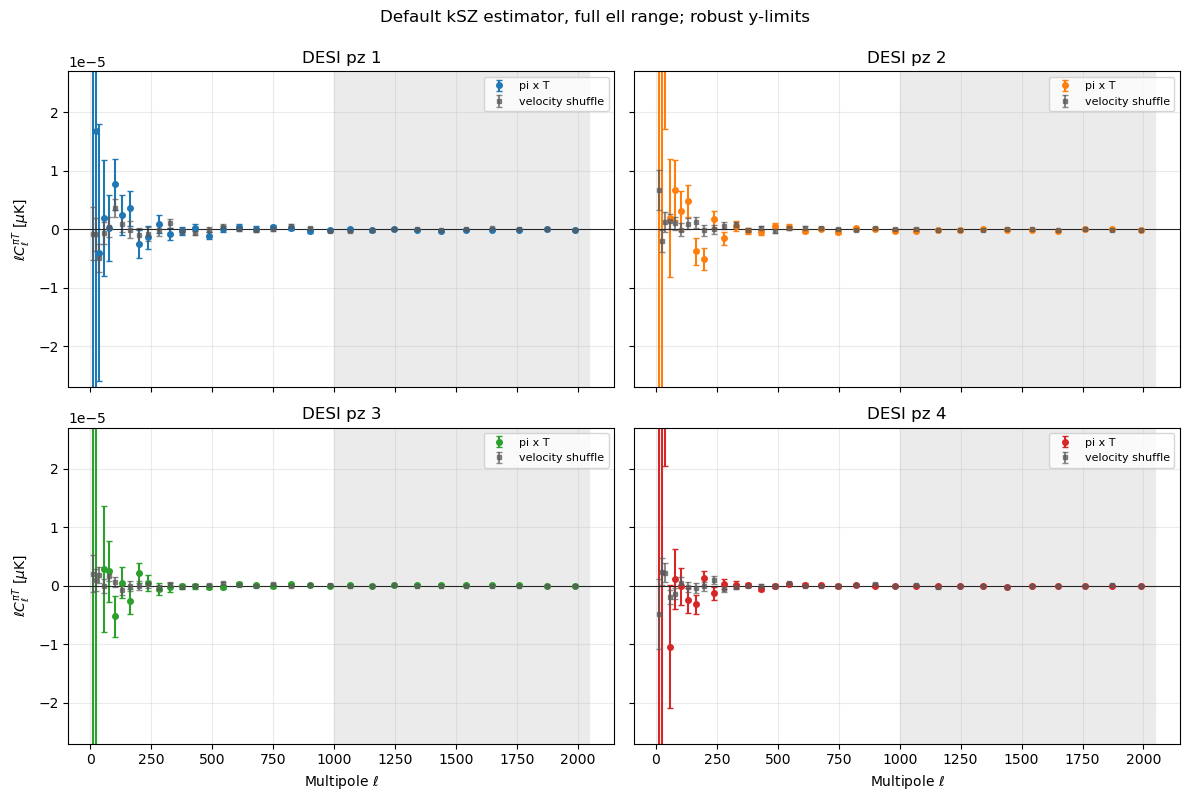

In [5]:
def spectrum(result, pz, shuffled=False):
    group = 'shuffle_spectra' if shuffled else 'spectra'
    prefix = 'shuffle_pi_act_T' if shuffled else 'desi_pi_act_T'
    return result[group][f'{prefix}_pz{pz}']

def y_arrays(result, pz, shuffled=False, signed=False):
    ell = np.asarray(result['ell'], float)
    s = spectrum(result, pz, shuffled=shuffled)
    cl = np.asarray(s['cl'], float)
    err = np.asarray(s.get('err', np.full_like(cl, np.nan)), float)
    sign = -1.0 if signed else 1.0
    return ell, sign * ell * cl, ell * err

def robust_ylim(items, q=97.0, floor=1e-12):
    vals = []
    for y, e in items:
        y = np.asarray(y, float)
        e = np.asarray(e, float)
        vals.append(np.abs(y[np.isfinite(y)]))
        vals.append(np.abs((y + e)[np.isfinite(y + e)]))
        vals.append(np.abs((y - e)[np.isfinite(y - e)]))
    vals = np.concatenate([v.ravel() for v in vals if v.size])
    if vals.size == 0:
        return -1.0, 1.0
    lim = max(np.nanpercentile(vals, q) * 1.2, floor)
    return -lim, lim

def plot_grid(result, title, signed=False, ell_min_plot=None, show_shuffle=True, q=97.0):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    selected_items = []
    masks = {}
    for pz in range(1, 5):
        ell, y, err = y_arrays(result, pz, signed=signed)
        m = np.ones_like(ell, dtype=bool)
        if ell_min_plot is not None:
            m &= ell >= ell_min_plot
        masks[pz] = m
        selected_items.append((y[m], err[m]))
        if show_shuffle:
            _, ys, es = y_arrays(result, pz, shuffled=True, signed=signed)
            selected_items.append((ys[m], es[m]))
    ylim = robust_ylim(selected_items, q=q)
    colors = plt.get_cmap('tab10').colors
    for pz, ax in enumerate(axes.flat, start=1):
        ell, y, err = y_arrays(result, pz, signed=signed)
        m = masks[pz]
        ax.errorbar(ell[m], y[m], yerr=err[m], fmt='o', ms=4, capsize=2, color=colors[pz-1], label='pi x T')
        if show_shuffle:
            _, ys, es = y_arrays(result, pz, shuffled=True, signed=signed)
            ax.errorbar(ell[m], ys[m], yerr=es[m], fmt='s', ms=3, capsize=2, color='0.35', alpha=0.7, label='velocity shuffle')
        ax.axhline(0, color='0.15', lw=0.8)
        ax.axvspan(1000, 2048, color='0.92', zorder=-10)
        ax.set_title(f'DESI pz {pz}')
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel(r'Multipole $\ell$')
    ylabel = r'$-\ell C_\ell^{\pi T}$ [$\mu$K]' if signed else r'$\ell C_\ell^{\pi T}$ [$\mu$K]'
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel)
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    return fig

plot_grid(default, 'Default kSZ estimator, full ell range; robust y-limits', signed=False, ell_min_plot=None, q=96.0);

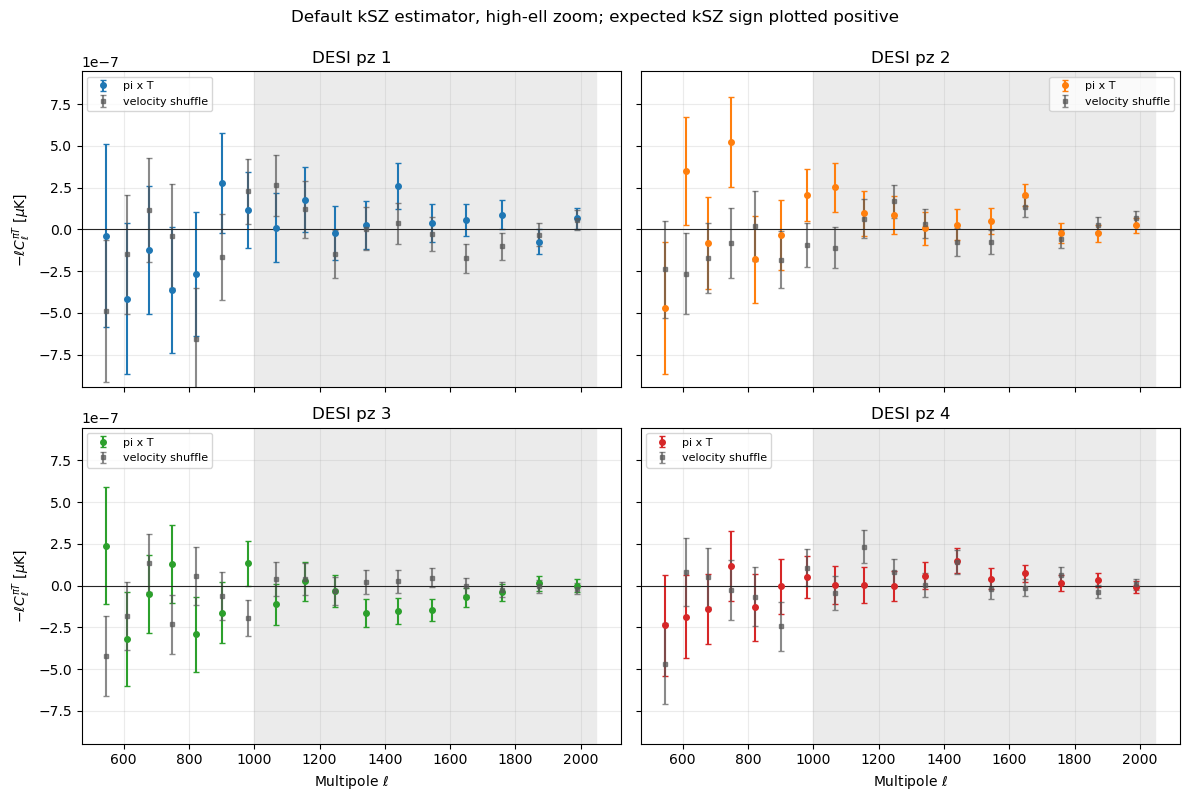

In [6]:
plot_grid(default, 'Default kSZ estimator, high-ell zoom; expected kSZ sign plotted positive', signed=True, ell_min_plot=500, q=99.0);

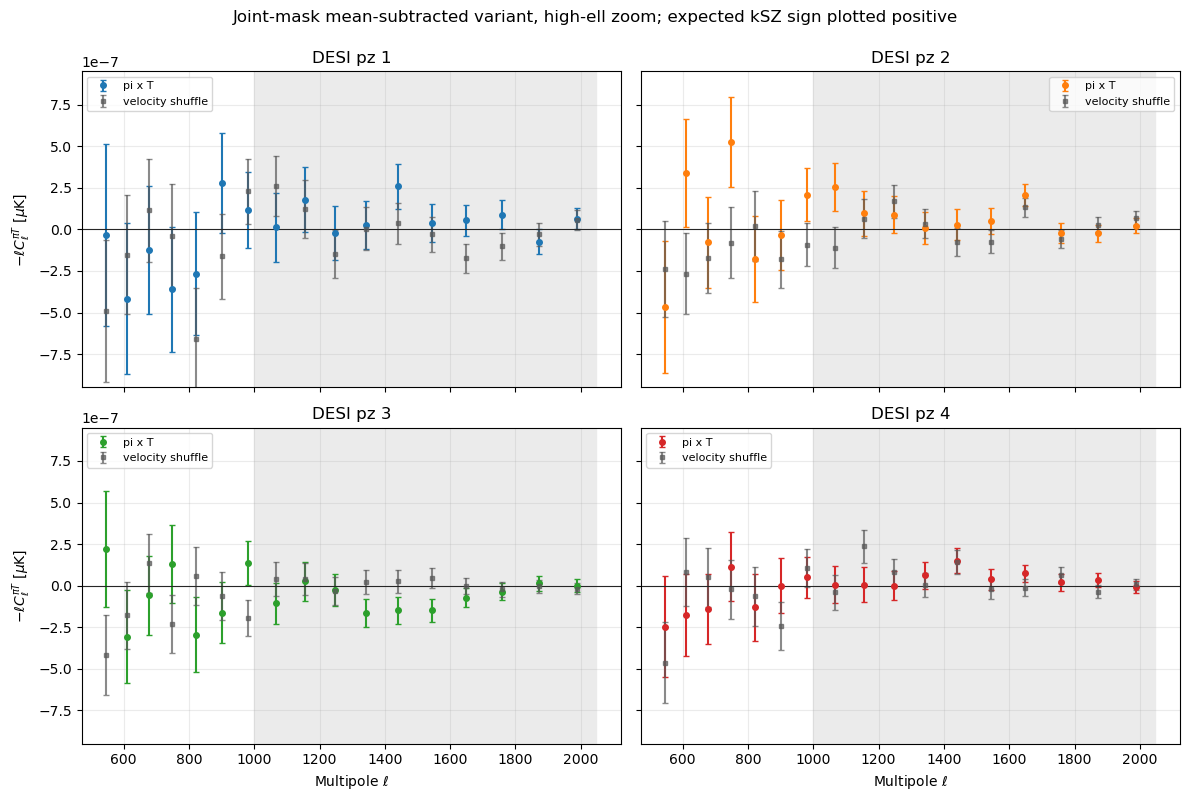

In [7]:
plot_grid(jointmean, 'Joint-mask mean-subtracted variant, high-ell zoom; expected kSZ sign plotted positive', signed=True, ell_min_plot=500, q=99.0);

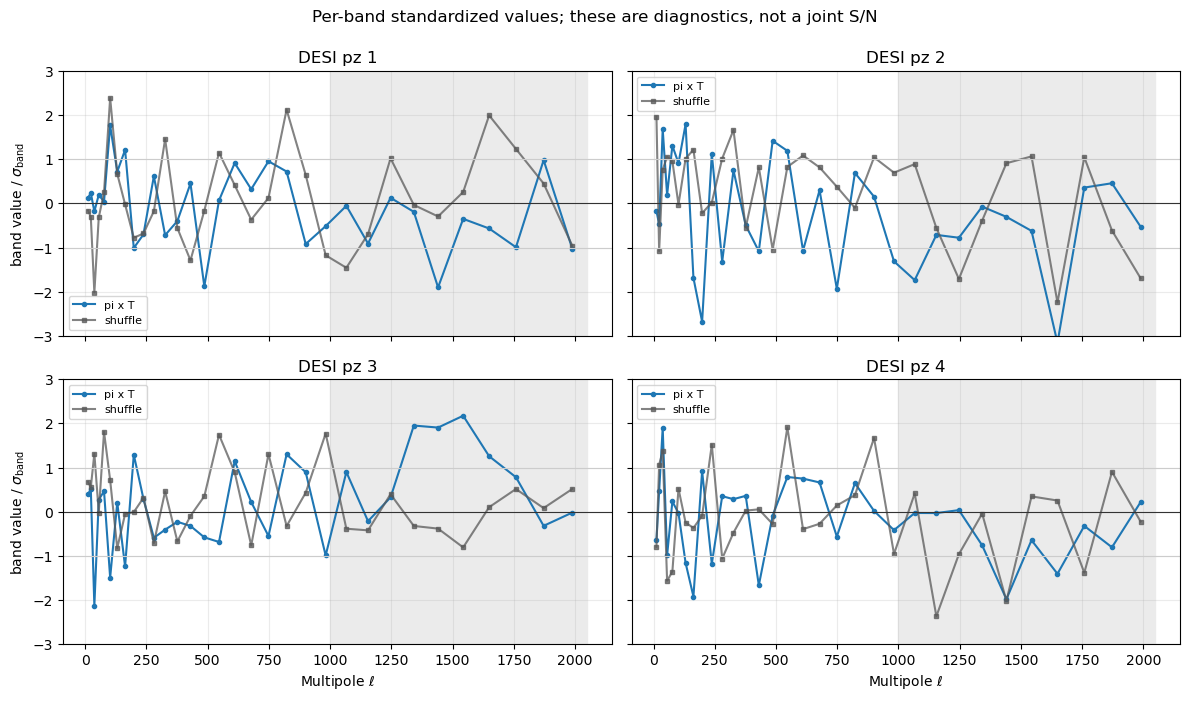

In [8]:
def plot_band_chi(result, title, ell_min_plot=0):
    ell = np.asarray(result['ell'], float)
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
    vals = []
    for pz in range(1, 5):
        _, y, err = y_arrays(result, pz, signed=False)
        vals.append(y / err)
        _, ys, es = y_arrays(result, pz, shuffled=True, signed=False)
        vals.append(ys / es)
    lim = max(3.0, np.nanpercentile(np.abs(np.concatenate(vals)), 98) * 1.15)
    for pz, ax in enumerate(axes.flat, start=1):
        m = ell >= ell_min_plot
        _, y, err = y_arrays(result, pz, signed=False)
        _, ys, es = y_arrays(result, pz, shuffled=True, signed=False)
        ax.plot(ell[m], (y / err)[m], 'o-', ms=3, label='pi x T')
        ax.plot(ell[m], (ys / es)[m], 's-', ms=3, color='0.35', alpha=0.75, label='shuffle')
        ax.axhline(0, color='0.2', lw=0.8)
        ax.axhline(1, color='0.8', lw=0.8)
        ax.axhline(-1, color='0.8', lw=0.8)
        ax.axvspan(1000, 2048, color='0.92', zorder=-10)
        ax.set_ylim(-lim, lim)
        ax.set_title(f'DESI pz {pz}')
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel(r'Multipole $\ell$')
    for ax in axes[:, 0]:
        ax.set_ylabel(r'band value / $\sigma_{\rm band}$')
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    return fig

plot_band_chi(default, 'Per-band standardized values; these are diagnostics, not a joint S/N', ell_min_plot=0);

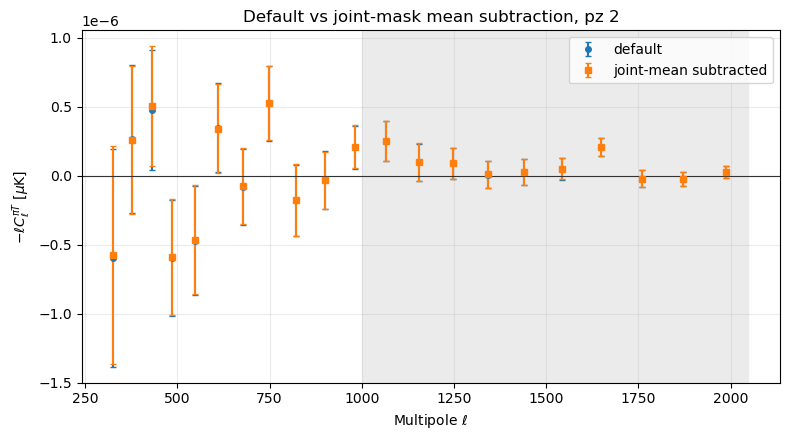

In [9]:
def plot_default_vs_jointmean(pz=2, signed=True, ell_min_plot=300):
    ell = np.asarray(default['ell'], float)
    m = ell >= ell_min_plot
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, result, marker in [('default', default, 'o'), ('joint-mean subtracted', jointmean, 's')]:
        _, y, err = y_arrays(result, pz, signed=signed)
        ax.errorbar(ell[m], y[m], yerr=err[m], fmt=marker, ms=4, capsize=2, label=label)
    ax.axhline(0, color='0.2', lw=0.8)
    ax.axvspan(1000, 2048, color='0.92', zorder=-10)
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$-\ell C_\ell^{\pi T}$ [$\mu$K]' if signed else r'$\ell C_\ell^{\pi T}$ [$\mu$K]')
    ax.set_title(f'Default vs joint-mask mean subtraction, pz {pz}')
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    return fig

plot_default_vs_jointmean(pz=2, signed=True, ell_min_plot=300);

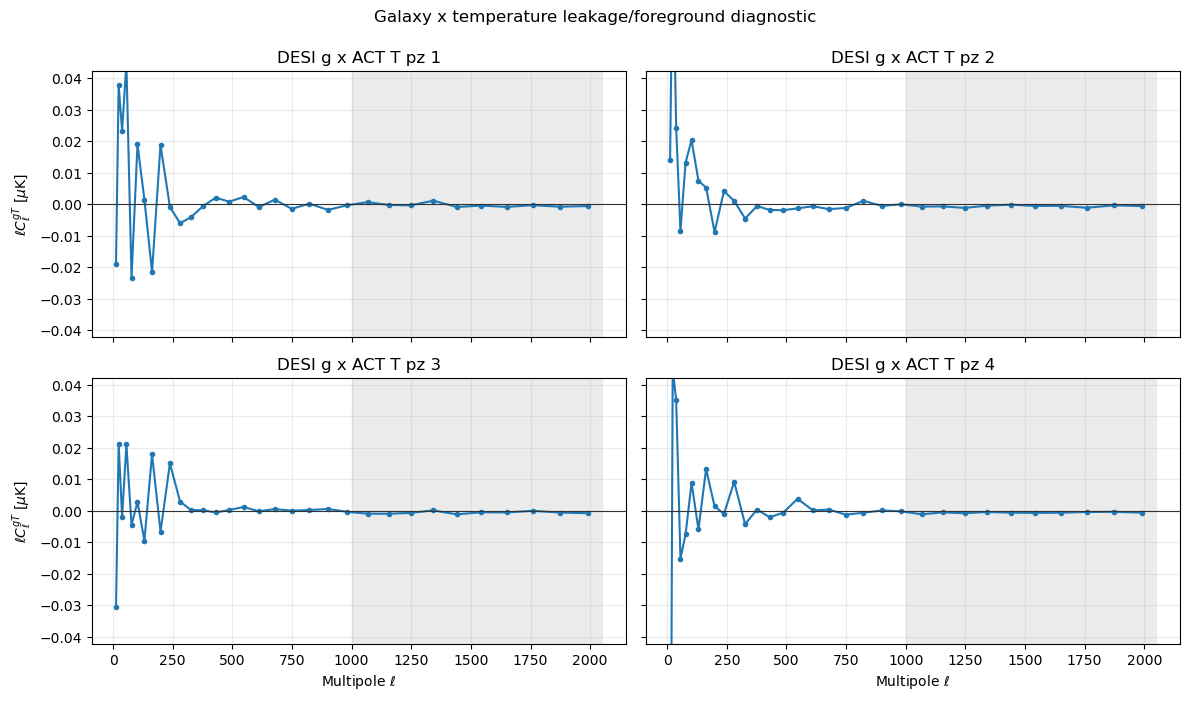

In [10]:
def plot_gT_leakage(result):
    ell = np.asarray(result['ell'], float)
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
    vals = []
    for pz in range(1,5):
        s = result['galaxy_temperature_spectra'][f'desi_g_act_T_pz{pz}']
        vals.append(ell * np.asarray(s['cl'], float))
    ylim = robust_ylim([(v, np.zeros_like(v)) for v in vals], q=96, floor=1e-8)
    for pz, ax in enumerate(axes.flat, start=1):
        s = result['galaxy_temperature_spectra'][f'desi_g_act_T_pz{pz}']
        y = ell * np.asarray(s['cl'], float)
        ax.plot(ell, y, 'o-', ms=3)
        ax.axhline(0, color='0.2', lw=0.8)
        ax.axvspan(1000, 2048, color='0.92', zorder=-10)
        ax.set_ylim(*ylim)
        ax.set_title(f'DESI g x ACT T pz {pz}')
        ax.grid(alpha=0.25)
    for ax in axes[-1]:
        ax.set_xlabel(r'Multipole $\ell$')
    for ax in axes[:, 0]:
        ax.set_ylabel(r'$\ell C_\ell^{gT}$ [$\mu$K]')
    fig.suptitle('Galaxy x temperature leakage/foreground diagnostic', y=0.995)
    fig.tight_layout()
    return fig

plot_gT_leakage(default);

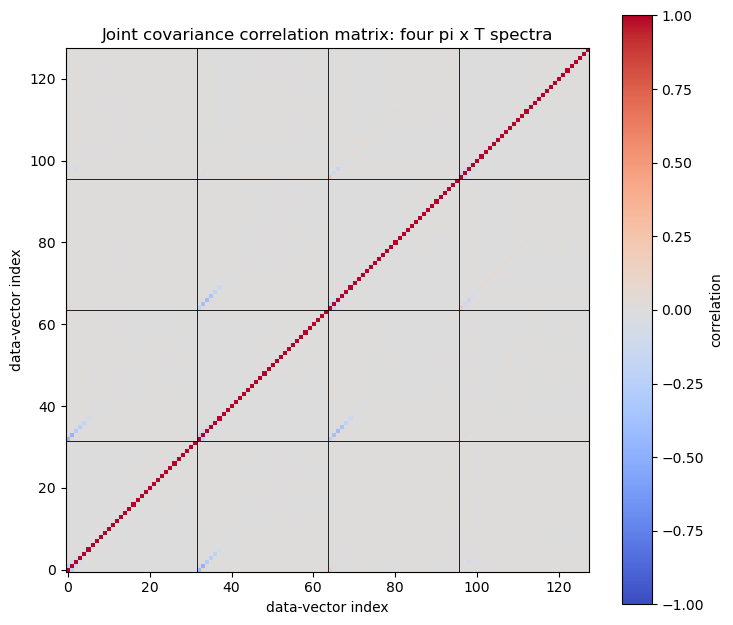

In [11]:
def plot_corr(result):
    cov = np.asarray(result['covariance'], float)
    diag = np.sqrt(np.clip(np.diag(cov), 0, np.inf))
    corr = np.divide(cov, diag[:, None] * diag[None, :], out=np.zeros_like(cov), where=(diag[:, None] * diag[None, :]) > 0)
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm', origin='lower')
    n = len(result['ell'])
    for k in range(1, 4):
        ax.axhline(k*n - 0.5, color='k', lw=0.6)
        ax.axvline(k*n - 0.5, color='k', lw=0.6)
    ax.set_title('Joint covariance correlation matrix: four pi x T spectra')
    ax.set_xlabel('data-vector index')
    ax.set_ylabel('data-vector index')
    fig.colorbar(im, ax=ax, label='correlation')
    fig.tight_layout()
    return fig

plot_corr(default);

## Interpretation Notes

- The low-resolution diagnostic only reaches `ell=2048`. The kSZ reference analyses use substantially higher multipoles, so this notebook is mainly a map/estimator sanity check.
- The plotted measured quantity is `C_ell^{pi,T_uK}` where `pi` is dimensionless reconstructed velocity over `c` and `T` is in micro-Kelvin.
- For a physically positive optical-depth cross-spectrum, the simple model predicts `C_ell^{pi,T} = -T_CMB_uK * A_v * C_ell^{g,tau}`. The high-ell zoom therefore also plots `-ell*C_ell` so the expected kSZ sign appears positive.
- The null-test table uses full-covariance chi-square and PTE. A template-amplitude S/N should be added once the theory wrapper produces a template vector on the same NaMaster bandpower windows.